In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

In [2]:
drive_path = os.path.join(os.getcwd(), "../dataset")

# Paths to your dataset
dataset_dir = drive_path + '/filtered/ImageCropped'


# Data Augmentation
datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',  # Specify this as validation data
    shuffle=False
)


Found 1657 images belonging to 10 classes.
Found 328 images belonging to 10 classes.


In [3]:
class_indices = train_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}

from collections import Counter

class_counts = Counter(train_generator.classes)
total_data_per_class = {class_names[k]: v for k, v in class_counts.items()}

train_histogram = {}
for class_name, count in total_data_per_class.items():
  train_histogram[class_name.split("-")[1]] = count
# print(train_histogram)

sorted_train_histogram = sorted(train_histogram.items(), key=lambda x: x[0], reverse=True)
# print(sorted_train_histogram, type(sorted_train_histogram))


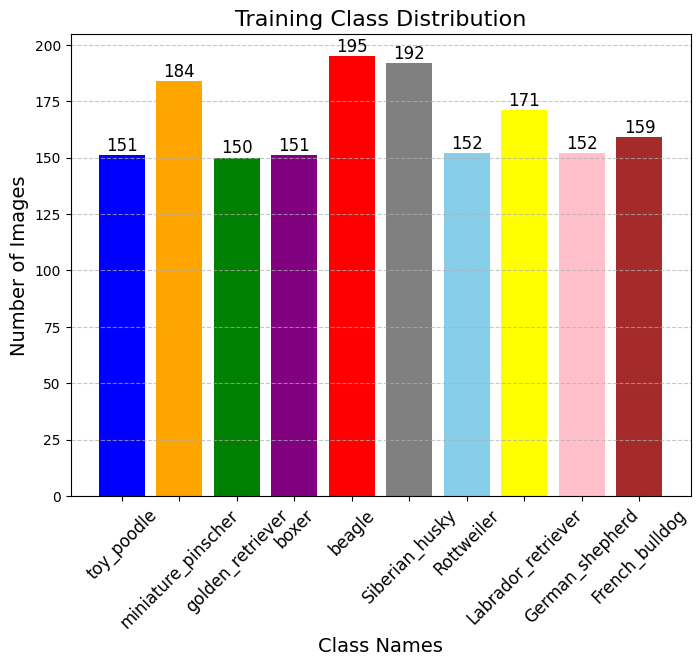

In [4]:
import matplotlib.pyplot as plt

# Class distribution data
class_names = []
class_counts = []
for item in sorted_train_histogram:
  class_names.append(item[0])
  class_counts.append(item[1])


# Plot the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(class_names, class_counts, color=['blue', 'orange', 'green', 'purple', 'red', 'gray', 'skyblue', 'yellow', 'pink', 'brown'])

# Add labels and title
plt.title('Training Class Distribution', fontsize=16)
plt.xlabel('Class Names', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=12)

# Annotate bar values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 2, str(yval), ha='center', fontsize=12)

plt.show()

In [5]:
class_indices = val_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}

from collections import Counter

class_counts = Counter(val_generator.classes)
total_data_per_class = {class_names[k]: v for k, v in class_counts.items()}

val_histogram = {}
for class_name, count in total_data_per_class.items():
  val_histogram[class_name.split("-")[1]] = count
# print(val_histogram)

sorted_val_histogram = sorted(val_histogram.items(), key=lambda x: x[0], reverse=True)
# print(sorted_val_histogram, type(sorted_val_histogram))

In [6]:
class_indices = val_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}

from collections import Counter

class_counts = Counter(val_generator.classes)
total_data_per_class = {class_names[k]: v for k, v in class_counts.items()}

val_histogram = {}
for class_name, count in total_data_per_class.items():
  val_histogram[class_name.split("-")[1]] = count
# print(val_histogram)

sorted_val_histogram = sorted(val_histogram.items(), key=lambda x: x[0], reverse=True)
# print(sorted_val_histogram, type(sorted_val_histogram))

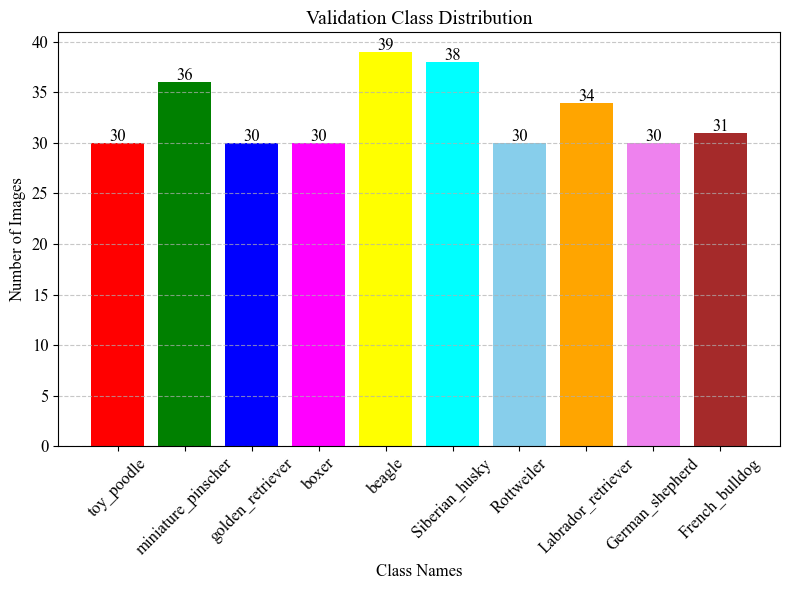

In [7]:
import matplotlib.pyplot as plt

# Class distribution data
class_names = []
class_counts = []
for item in sorted_val_histogram:
  class_names.append(item[0])
  class_counts.append(item[1])


# Plot the bar chart
plt.figure(figsize=(8, 6))
plt.rcParams['font.family'] = 'Times New Roman'
bars = plt.bar(class_names, class_counts, color=['red', 'green', 'blue', 'magenta', 'yellow', 'cyan', 'skyblue', 'orange', 'violet', 'brown', 'gray', 'lightgray'])

# Add labels and title

plt.title('Validation Class Distribution', fontsize=14)
plt.xlabel('Class Names', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Annotate bar values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.2, str(yval), ha='center', fontsize=12)
image_path = os.path.join(os.getcwd(), "../val_data.png")
plt.tight_layout()
plt.savefig(image_path)
plt.show()

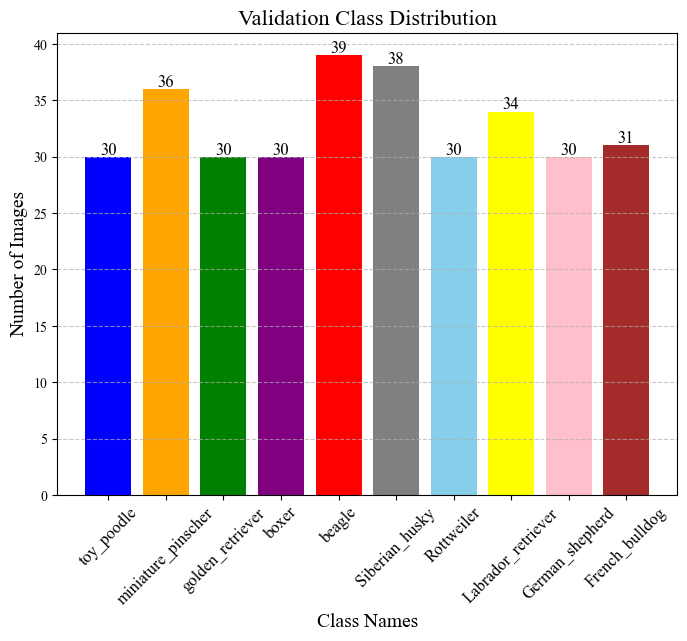

In [8]:
import matplotlib.pyplot as plt

# Class distribution data
class_names = []
class_counts = []
for item in sorted_val_histogram:
  class_names.append(item[0])
  class_counts.append(item[1])


# Plot the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(class_names, class_counts, color=['blue', 'orange', 'green', 'purple', 'red', 'gray', 'skyblue', 'yellow', 'pink', 'brown'])

# Add labels and title
plt.title('Validation Class Distribution', fontsize=16)
plt.xlabel('Class Names', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=12)

# Annotate bar values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.2, str(yval), ha='center', fontsize=12)

plt.show()

In [9]:
# model.summary()

In [10]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import NASNetLarge
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

def create_model(base_model_type='InceptionV3', num_classes=120):  # Adjust classes based on breeds
    if base_model_type == 'InceptionV3':
        base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    elif base_model_type == 'NASNetLarge':
        base_model = NASNetLarge(weights='imagenet', include_top=False, input_shape=(331, 331, 3))
    else:
        raise ValueError("Unsupported base model type.")

    # Add custom layers for breed-specific classification
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False

    return model

model = create_model(base_model_type='InceptionV3', num_classes=10)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [11]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_steps=val_generator.samples // val_generator.batch_size
)


D:\lab\myproj\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2476 - loss: 5.4903

D:\lab\myproj\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


51/51 ━━━━━━━━━━━━━━━━━━━━ 222s 4s/step - accuracy: 0.2510 - loss: 5.4460 - val_accuracy: 0.8531 - val_loss: 0.6495
Epoch 2/10
 1/51 ━━━━━━━━━━━━━━━━━━━━ 1:42 2s/step - accuracy: 0.7500 - loss: 0.8314

D:\lab\myproj\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 516ms/step - accuracy: 0.7500 - loss: 0.8314 - val_accuracy: 0.8656 - val_loss: 0.6093
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.8456 - loss: 0.6160 - val_accuracy: 0.9688 - val_loss: 0.1513
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 507ms/step - accuracy: 0.9375 - loss: 0.1892 - val_accuracy: 0.9688 - val_loss: 0.1448
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.9211 - loss: 0.2911 - val_accuracy: 0.9406 - val_loss: 0.1848
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 507ms/step - accuracy: 0.9375 - loss: 0.3209 - val_accuracy: 0.9312 - val_loss: 0.2221
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.9387 - loss: 0.2230 - val_accuracy: 0.9594 - val_loss: 0.1336
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 505ms/step - accuracy: 0.9688 - loss: 0.0922 - val_accuracy: 0.9438 - val_loss: 0.1538
Epoch 9/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.9516 - loss: 0.1668 - val_accuracy: 0.9750 - val_

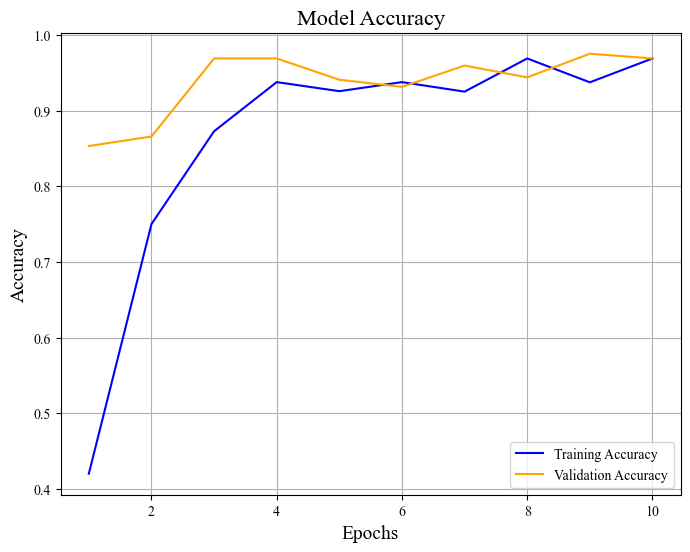

In [12]:
# Extract training and validation accuracy from the history object
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot the training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')

# Add labels and title
plt.title('Model Accuracy', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step


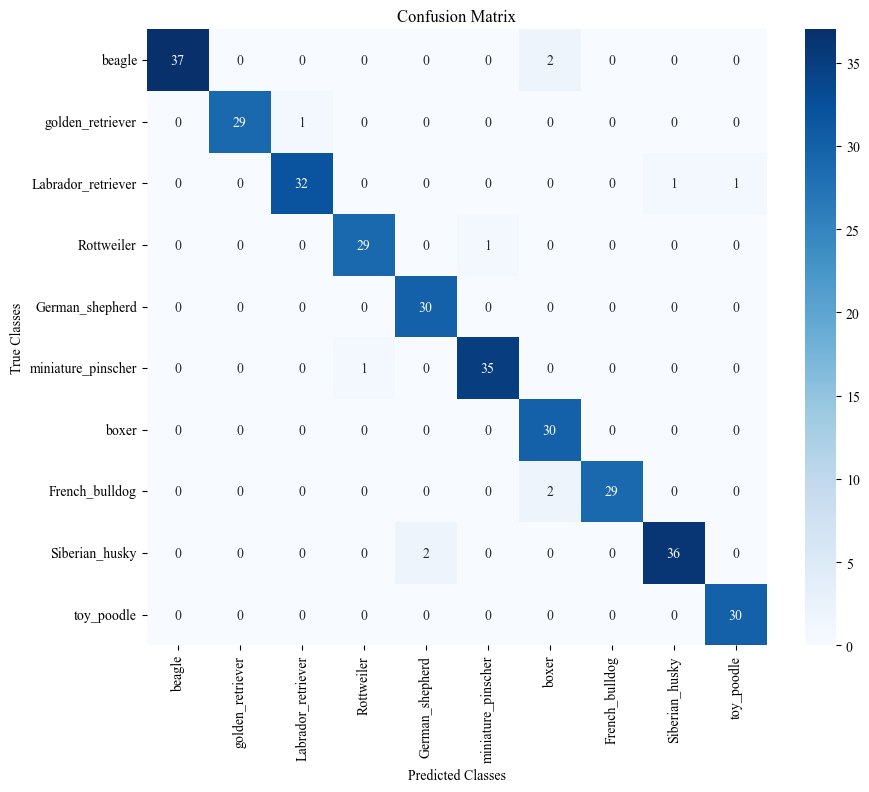

In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


y_true = val_generator.classes  # True labels
class_indices = val_generator.class_indices  # Class mapping
classes = list(class_indices.keys())  # Class names
classes = [x.split("-")[1] for x in classes]

# Predict probabilities
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)


# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Classes')
plt.ylabel('True Classes')
plt.title('Confusion Matrix')
plt.show()

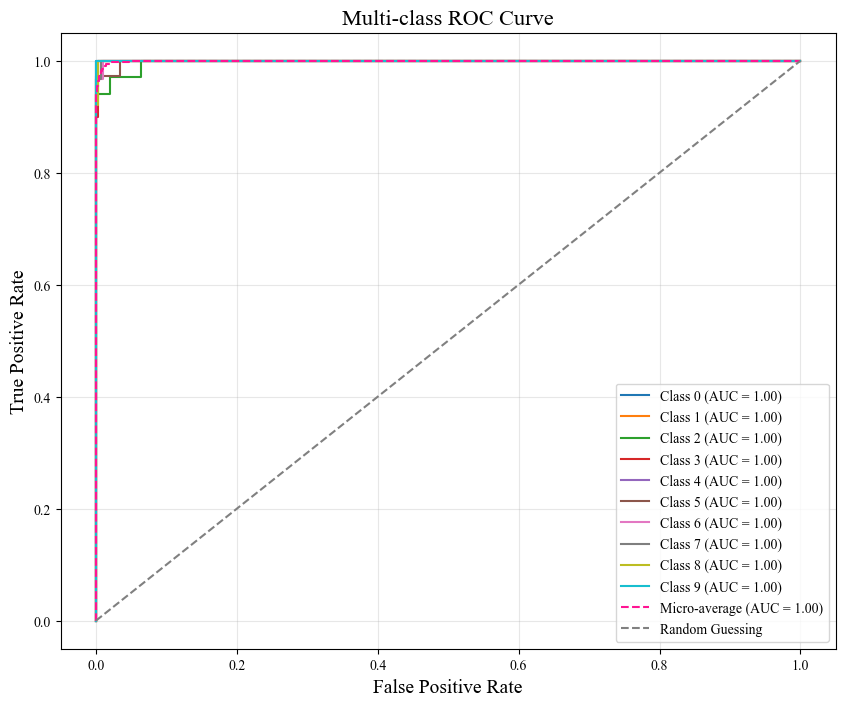

In [16]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle

# Number of classes
n_classes = y_pred_probs.shape[1]

# Binarize the true labels (for multi-class ROC curve)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# Plotting the ROC curve
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

# Micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
plt.plot(fpr["micro"], tpr["micro"], linestyle='--', label=f"Micro-average (AUC = {roc_auc['micro']:.2f})", color='deeppink')

# Add diagonal line for random guessing
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guessing")

# Plot formatting
plt.title("Multi-class ROC Curve", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
